In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import netCDF4 as nc
import xarray as xr
import datetime as dt
from salishsea_tools import evaltools as et, viz_tools, places
import gsw 
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.dates as mdates
import cmocean as cmo
import scipy.interpolate as sinterp
import math
from scipy import io
import pickle
import cmocean
from salishsea_tools import Keegan_eval_tools as ket
import json
from collections import OrderedDict
from matplotlib.colors import LogNorm
import arrow
import glob
import datetime
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib.dates import HourLocator, MonthLocator, YearLocator

fs=16
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')

import warnings
#warnings.filterwarnings('ignore')
from IPython.display import Markdown, display

%matplotlib inline

In [2]:
JdF = [300,365, 50, 100]

In [3]:
with nc.Dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc') as mesh:
    e3t = np.copy(mesh.variables['e3t_0'][0,0:24,:,:])
    tmask=np.copy(mesh.variables['tmask'][0,0:24,:,:])

    # Load variables
    e3t  = mesh.variables['e3t_0'][0, 0:24, :, :]
    tmask = mesh.variables['tmask'][0, 0:24, :, :]

    e1t = mesh.variables['e1t'][:, :]
    e2t = mesh.variables['e2t'][:, :]

    # Expand e1t and e2t to match 3D vertical shape
    e1t_3d = np.broadcast_to(e1t, e3t.shape)
    e2t_3d = np.broadcast_to(e2t, e3t.shape)

    # Compute volume
    volume = tmask * e1t_3d * e2t_3d * e3t

    # Slice box
    denominator = np.nansum(volume[:, 300:365, 50:100])

In [4]:
yearList = [2014, 2015, 2016, 2017]
data = 'month-avg.202111'
file = 'prod'

# months April (4) to September (9)
months = range(4, 10)

# Collect all files for the desired years and months
files = []
for year in yearList:
    for month in months:
        matched = glob.glob(f'/results2/SalishSea/{data}/SalishSeaCast_1m_{file}_T_*{year}*{month:02d}01_*{year}*{month:02d}??.nc')
        files.extend(matched)

print(f"Found {len(files)} files")

# Now open them with xarray
ds = xr.open_mfdataset(files, combine='by_coords')

# Extract the variable
PPDIATNO3 = ds['PPDIATNO3']
PPPHYNO3 = ds['PPPHYNO3']

# Optional: check the shape
print(PPDIATNO3.shape)

Found 24 files
(24, 40, 898, 398)


In [5]:
PP_total = PPDIATNO3 + PPPHYNO3

In [6]:
MHW_PP_mean = np.mean(PP_total,axis=0)

In [7]:
np.shape(MHW_PP_mean)

(40, 898, 398)

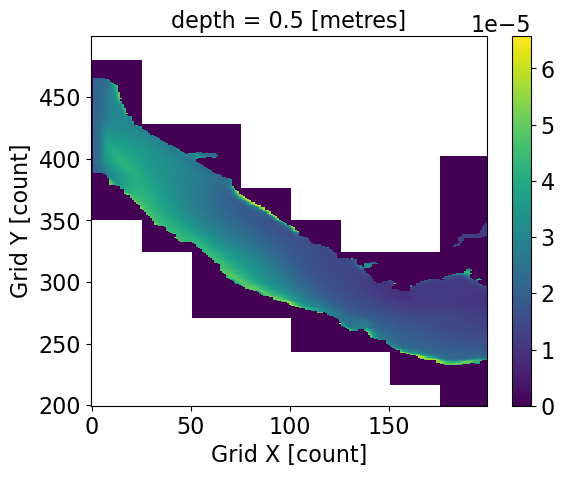

In [8]:
MHW_PP_mean[0, 200:500, 0:200].plot();

In [9]:
MHW_numerator=np.nansum(
    np.array(MHW_PP_mean[0:24, 300:365, 50:100]) * np.array(volume[0:24, 300:365, 50:100]))

In [10]:
MHW_average_productivity = MHW_numerator/denominator * 86400
MHW_average_productivity

0.34548339633090996

## Dataset for climatology

In [11]:
clim=nc.Dataset('/results2/SalishSea/month-avg.202111/SalishSeaCast_month_climatology_prod_T_20070101_20231231.nc')

In [12]:
clim.variables.keys()

dict_keys(['PPDIAT', 'PPPHY', 'PPDIATNO3', 'PPPHYNO3', 'TQ10', 'depth', 'gridY', 'gridX', 'month'])

In [13]:

months_apr_sep = slice(3, 9)  # selects 3,4,5,6,7,8 = Apr-Sep

Clim_PP_mean = np.mean(clim['PPDIATNO3'][months_apr_sep] + clim['PPPHYNO3'][months_apr_sep],axis=0)


In [14]:
np.shape(Clim_PP_mean)

(40, 898, 398)

In [15]:
Clim_numerator=np.nansum(
    np.array(Clim_PP_mean[0:24, 300:365, 50:100]) * np.array(volume[0:24, 300:365, 50:100]))

In [16]:
Clim_average_productivity = Clim_numerator/denominator * 86400
Clim_average_productivity

0.33469772421218846

In [17]:
# Central part of JdF Strait about 60 km long
# Currents in July in upper JdF about 30 cm/s based on Thomson et al 2007 Fig 6
time = 60e3/0.3 / 86400 # in days
time

2.314814814814815

In [20]:
time * (MHW_average_productivity - Clim_average_productivity)

0.024966833608151624

In [22]:
time * (MHW_average_productivity - Clim_average_productivity) / 0.47 # nitrate anomaly during the same depth/month/time

0.05312092257053537